
## Trading Hypothesis Development - Moving Averages.
* Suppose we believe that when prices have been rising, they will continue to go up.
    * This reflects the idea that prices exhibit momentum, it is a distinct from the idea that prices revert to a mean.
    
    
* Consequently, we may hypothesize that when the 20-day average of prices is greater than the 60-day average, prices will continue to rise. 
    * Alternatively, when the 20-day average is below the 60-day  average, prices will fall.
    

* Compute the mean daily return of this strategy for our Apple stock price sample (January 1, 2004 to December 31, 2019). 
    * You may use monthly holding periods.
    
### This practice exercise sets us up to implement one of the most important findings in empirical finance.

In [1]:
import pandas_ta as ta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader.data import DataReader
from datetime import date, datetime, timedelta

In [2]:
dj_stocks_close = pd.read_csv('data/dj_stocks_close.csv', parse_dates=['date'], index_col='date')
dj_stocks_close.fillna('ffill')
#dj_stocks_close = dj_stocks_close['2015-1-1':'2019-12-31']

df = dj_stocks_close['AAPL'].to_frame()
df.columns = ['price']
df

,price
date,
2004-01-02,0.327318
2004-01-05,0.341008
2004-01-06,0.339777
2004-01-07,0.347468
2004-01-08,0.359312
...,...
2019-12-24,70.353882
2019-12-26,71.749733
2019-12-27,71.722488


## **Compute Moving Averages**
* The Pandas Technical Analysis Library allows us to compute several indicators, including moving averages:

    * https://pypi.org/project/pandas-ta/
    
    * pip install pandas_ta
* To compute moving averages of prices, explore the Pandas Technical Library.
    * Find the appropriate function.
    * Use this function to compute the 20 and 60-day moving average for our price data. 

In [3]:
SMA_20 = ta.sma(dj_stocks_close['AAPL'], length=20)
SMA_60  = ta.sma(dj_stocks_close['AAPL'], length=60)
pd.DataFrame(SMA_20).tail()

,SMA_20
date,
2019-12-24,67.336241
2019-12-26,67.653276
2019-12-27,67.925019
2019-12-30,68.225348
2019-12-31,68.590271


### **Formulate the Strategy in Python**
        
* Create a numerical variable called buyPositions, which stores the result of comparing short average to long average.
    * buyPositions = 1 or 0
* Similarly, create a variable called sellPositions.
    * sellPositions = -1 or 0
* Finally, create an overall position variable positionsMA as follows: 
    * positions = buyPositions + sellPositions

In [4]:
buyPositions  = (SMA_20  > SMA_60).astype(int) * 1
sellPositions = (SMA_20 < SMA_60).astype(int)  * -1


positions = buyPositions + sellPositions

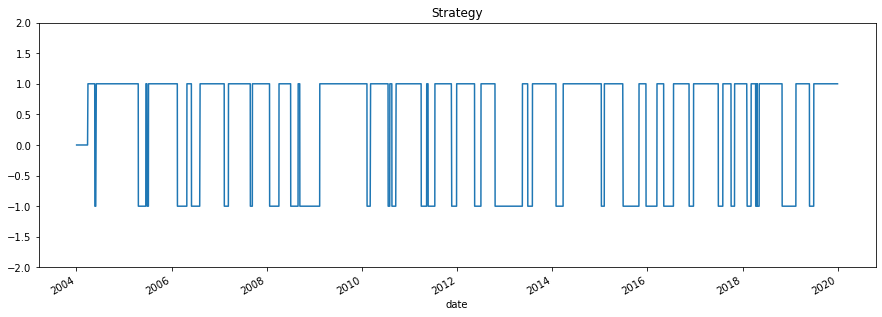

In [5]:
positions.plot(title="Strategy",ylim=(-2,2),figsize=(15,5))
None

### **Computing monthly returns.**
* First obtain month-end prices.
    * Resample daily prices at a monthly frequency to obtain monthly prices
    * monthly_prices = prices.resample('M').last()
    
* Monthly returns can then be computed from monthly prices:
    * Returns measure changes in prices.
    * For each period t in the sample, a return R<sub>t</sub> can be computed.
    * R<sub>t</sub>  = (P<sub>t</sub> - P<sub>t-1</sub>)/P<sub>t-1</sub>.    
    
* pct_change() suffices here.


In [6]:
### TO DO: create monthly returns
df_monthly = df.resample('M').last()
df_monthly['returns'] = df_monthly['price'].pct_change()
df_monthly['lookahead_returns'] = df_monthly['returns'].shift(-1)
df_monthly.head()

,price,returns,lookahead_returns
date,,,
2004-01-31,0.347006,NaN,0.060285
2004-02-29,0.367925,0.060285,0.130434
2004-03-31,0.415915,0.130434,-0.046598
2004-04-30,0.396535,-0.046598,0.088440
2004-05-31,0.431604,0.088440,0.159659


### **Compute Returns earned by Strategy each Period**

* Given the position taken at the beginning of a period, we can compute the return that position will earn in the subsequent period.
positions*lookahead_returns

    * To create subsequent periods returns you may find df.shift(-1) method helpful.
    * In this way, we can compute the returns the strategy earns each period.
 


In [7]:
#stratReturns = (positions*lookahead_returns).dropna()
stratReturns = (positions*df_monthly['lookahead_returns']).dropna()
pd.DataFrame(stratReturns, columns=['stratReturns']).head()

,stratReturns
date,
2004-03-31,-0.046598
2004-04-30,0.088440
2004-06-30,-0.006146
2004-08-31,0.123513
2004-09-30,0.352258


### **Compute the mean return earned by the strategy**
        
* The Strategy earns a return each period.
    * Compute the mean return earned by the strategy over the full sample
    
    
* Annualize the mean return
    * The holding period for the strategy is monthly
    * The mean return we have computed is for one month.
    * To annualize the mean, we multiply it by 12.

In [8]:
stratReturnsMean = stratReturns.mean()
stratReturnsstd = stratReturns.std()
print(stratReturnsMean)


0.011066868468617465


In [9]:
annConst = 12
stratReturnsMeanAnnualRate = stratReturnsMean * annConst
print(stratReturnsMeanAnnualRate)

0.13280242162340958


##  **A "Mean Reverting" Trading Signal.**

* Suppose we believe that whenever prices are greater than the upper Bollinger band, they will fall.
* On the other hand, when prices are below the lower Bollinger band, they will rise.
    * bb = ta.bbands(df['price'], length = 10)
    * bb.columns = ['low_band', 'mid_band', 'up_band']


*  In this case, Buy and Sell signals might reflect the following strategy :

| Signal | Condition |
|----|------|
| 1 | Close Price < Down |
| -1  | Close Price > Up |
| 0  | Otherwise |
